<a href="https://colab.research.google.com/github/m00n07/mineria_de_datos/blob/main/ExamenFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Agua y café

In [1]:

import pandas as pd
import numpy as np


# Establece una semilla para reproducibilidad
np.random.seed(42)


# 1. Crea una lista de matrículas de estudiantes
student_ids = [f'{i:06d}' for i in range(172120, 172120 + 20)]


# 2. Asigna 10 estudiantes al grupo 'Café' y 10 al grupo 'Agua'
groups = ['Café'] * 10 + ['Agua'] * 10
np.random.shuffle(groups)


# 3. Simula calificacionen de examenes para el grupo café
# Mean=70, Std=5, asegurate de que los valores estén entre (50-100)
coffee_scores = np.random.normal(loc=70, scale=5, size=10).round(0)
coffee_scores = np.clip(coffee_scores, 50, 100).astype(int)


# 4. Simula calificaciones de examen para el grupo de 'Agua'
# Mean=75, Std=5, asegurate de que los valores estén entre (50-100)
water_scores = np.random.normal(loc=75, scale=5, size=10).round(0)
water_scores = np.clip(water_scores, 50, 100).astype(int)


# Combina los valores basado en el grupo
exam_scores = []
coffee_idx = 0
water_idx = 0
for group in groups:
    if group == 'Café':
        exam_scores.append(coffee_scores[coffee_idx])
        coffee_idx += 1
    else:
        exam_scores.append(water_scores[water_idx])
        water_idx += 1


# 5. Combina en un DataFrame de Pandas
df_students = pd.DataFrame({
    'Matrícula': student_ids,
    'Grupo': groups,
    'Calificaciones': exam_scores
})


print("Datos simulados:")
print(df_students.head())

Datos simulados:
  Matrícula Grupo  Calificaciones
0    172120  Café              77
1    172121  Agua              77
2    172122  Agua              79
3    172123  Café              78
4    172124  Café              58


Pregunta 4

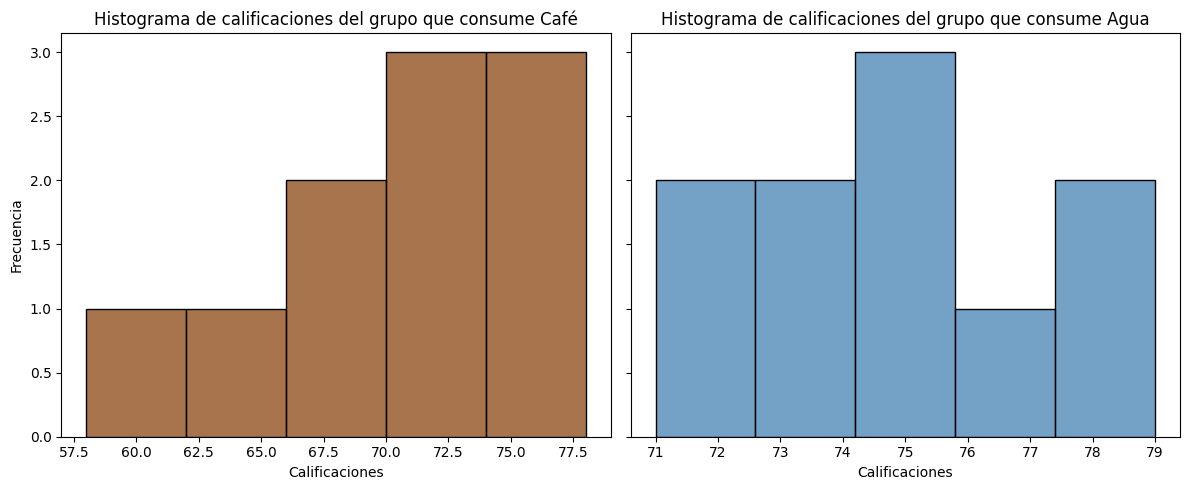


--- Tabla de datos completa ---
   Matrícula Grupo  Calificaciones
0     172120  Café              77
1     172121  Agua              77
2     172122  Agua              79
3     172123  Café              78
4     172124  Café              58
5     172125  Café              73
6     172126  Agua              74
7     172127  Café              69
8     172128  Agua              75
9     172129  Agua              75
10    172130  Agua              78
11    172131  Café              69
12    172132  Café              63
13    172133  Agua              74
14    172134  Café              77
15    172135  Agua              75
16    172136  Café              70
17    172137  Agua              71
18    172138  Agua              71
19    172139  Café              72


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Separamos los datos de cada grupo para graficarlos
df_cafe = df_students[df_students['Grupo'] == 'Café']
df_agua = df_students[df_students['Grupo'] == 'Agua']

# Configuramos la figura con dos subgráficas (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Histograma para el grupo de Café (Color café/marrón)
sns.histplot(data=df_cafe, x='Calificaciones', ax=axes[0], color='#8B4513', edgecolor='black')
axes[0].set_title('Histograma de calificaciones del grupo que consume Café')
axes[0].set_xlabel('Calificaciones')
axes[0].set_ylabel('Frecuencia')

# Histograma para el grupo de Agua (Color azul)
sns.histplot(data=df_agua, x='Calificaciones', ax=axes[1], color='#4682B4', edgecolor='black')
axes[1].set_title('Histograma de calificaciones del grupo que consume Agua')
axes[1].set_xlabel('Calificaciones')
axes[1].set_ylabel('') # Ocultamos la etiqueta Y en el segundo para que no se duplique

# Ajustamos el diseño y mostramos las gráficas
plt.tight_layout()
plt.show()

# También mostramos la tabla completa de datos en la consola
print("\n--- Tabla de datos completa ---")
print(df_students)

Question 17

Calcula la media (promedio) de los estudiantes que consumen café

In [6]:
cafe_mean_score = df_students[df_students['Grupo'] == 'Café']['Calificaciones'].mean()
print(f"La media de calificaciones de los estudiantes que consumen Café es: {cafe_mean_score:.2f}")

La media de calificaciones de los estudiantes que consumen Café es: 70.60


Pregunta 20
Calcula la media (promedio) de los estudiantes que consumen agua

In [13]:
water_mean_score = df_students[df_students['Grupo'] == 'Agua']['Calificaciones'].mean()
print(f"La media de calificaciones de los estudiantes que consumen Agua es: {water_mean_score:.2f}")

La media de calificaciones de los estudiantes que consumen Agua es: 74.90


# Problema de probabilidad condicional

Pregunta 7

In [8]:
# Given probabilities
P_A = 0.60
P_B = 0.40
P_D_A = 0.02
P_D_B = 0.05

P_D = (P_D_given_A * P_A) + (P_D_given_B * P_B)

P_B_given_D = (P_D_given_B * P_B) / P_D

print(f"La probabilidad de que la pieza haya sido fabricada por la máquina B, dado que es defectuosa, es: {P_B_given_D:.3f}")

La probabilidad de que la pieza haya sido fabricada por la máquina B, dado que es defectuosa, es: 0.625


# Tabla de contingencia de curso vs. examen

Pregunta 9

In [9]:
import pandas as pd

# 1. Crear el DataFrame con los datos de la tabla de contingencia
data = {
    'Aprobó': [45, 20],
    'Reprobó': [5, 30]
}
df = pd.DataFrame(data, index=['Tomó el curso', 'No tomó el curso'])

# Añadir los totales para verificar que coincida con la imagen
df['Total'] = df.sum(axis=1)
df.loc['Total'] = df.sum(axis=0)

print("--- Tabla de Contingencia ---")
print(df)
print("\n" + "="*30 + "\n")

# 2. Calcular la probabilidad condicional: P(Aprobó | Tomó el curso)
# Fórmula directa desde las frecuencias de la tabla:
# P(A|B) = Casos de (Aprobó Y Tomó el curso) / Total de (Tomó el curso)

casos_favorables = df.loc['Tomó el curso', 'Aprobó']
total_condicion = df.loc['Tomó el curso', 'Total']

probabilidad_condicional = casos_favorables / total_condicion

print(f"Casos (Aprobó y Tomó el curso): {casos_favorables}")
print(f"Total que Tomó el curso: {total_condicion}")
print(f"P(Aprobó | Tomó el curso) = {probabilidad_condicional} ({probabilidad_condicional * 100}%)")

--- Tabla de Contingencia ---
                  Aprobó  Reprobó  Total
Tomó el curso         45        5     50
No tomó el curso      20       30     50
Total                 65       35    100


Casos (Aprobó y Tomó el curso): 45
Total que Tomó el curso: 50
P(Aprobó | Tomó el curso) = 0.9 (90.0%)


pregunta 10

In [10]:
# Calcula la probabilidad simple de aprobar: P(Aprobó)
# P(Aprobó) = Total de Aprobó / Gran Total

total_aprobados = df.loc['Total', 'Aprobó']
gran_total = df.loc['Total', 'Total']

probabilidad_simple_aprobar = total_aprobados / gran_total

print(f"Total de estudiantes que aprobaron: {total_aprobados}")
print(f"Gran total de estudiantes: {gran_total}")
print(f"P(Aprobó) = {probabilidad_simple_aprobar} ({probabilidad_simple_aprobar * 100:.1f}%)")

Total de estudiantes que aprobaron: 65
Gran total de estudiantes: 100
P(Aprobó) = 0.65 (65.0%)


# Problema práctico de cálculo de RMSE

pregunta 14

In [12]:
import numpy as np

# Valores observados y predichos
observados = np.array([3, 7, 5, 10])
predichos = np.array([2, 8, 4, 9])

# 1. Calcular las diferencias
diferencias = observados - predichos

# 2. Elevar al cuadrado las diferencias
diferencias_cuadrado = diferencias**2

# 3. Calcular la media de las diferencias al cuadrado (MSE)
mse = np.mean(diferencias_cuadrado)

# 4. Calcular la raíz cuadrada de la MSE (RMSE)
rmse = np.sqrt(mse)

print(f"Valores Observados: {observados}")
print(f"Valores Predichos: {predichos}")
print(f"Diferencias: {diferencias}")
print(f"Diferencias al cuadrado: {diferencias_cuadrado}")
print(f"MSE (Error Cuadrático Medio): {mse:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f}")

Valores Observados: [ 3  7  5 10]
Valores Predichos: [2 8 4 9]
Diferencias: [ 1 -1  1  1]
Diferencias al cuadrado: [1 1 1 1]
MSE (Error Cuadrático Medio): 1.00
RMSE (Raíz del Error Cuadrático Medio): 1.00


# sensores

pregunta 22

In [15]:
import pandas as pd

# 1. Carga el CSV y selecciona solo las columnas requeridas
# NOTA: Reemplaza 'tu_archivo.csv' por la ruta o nombre real de tu archivo de datos
df_completo = pd.read_csv('/content/sensores.csv')
df = df_completo[['ts', 'temperatura', 'humedad']].copy()

# 2. Convierte ts a datetime manejando formatos mixtos y coercionando errores a NaT
df['ts'] = pd.to_datetime(df['ts'], format='mixed', errors='coerce')

# Calcular los valores de imputación ANTES de llenar los vacíos
mediana_temp_original = df['temperatura'].median()
media_hum_original = df['humedad'].mean()

# 3. Reemplaza valores faltantes en temperatura con la mediana y en humedad con la media
df['temperatura'] = df['temperatura'].fillna(mediana_temp_original)
df['humedad'] = df['humedad'].fillna(media_hum_original)

# 4. Reporta los resultados requeridos
# (a) ¿Cuántos NaT quedaron en ts?
nat_count = df['ts'].isna().sum()

# (b) Valor final de la mediana de temperatura tras imputación (redondeado a 1 decimal)
# Nota: La mediana no cambia tras imputar con la misma mediana, pero se recalcula para asegurar
final_median_temp = round(df['temperatura'].median(), 1)

# (c) Valor final de la media de humedad tras imputación (redondeado a 3 decimales)
# Nota: La media no cambia numéricamente tras imputar con la misma media, se recalcula para asegurar
final_mean_hum = round(df['humedad'].mean(), 3)

# Mostrar los resultados listos en el formato de entrega
print("--- RESULTADOS PARA ENTREGA ---")
print(f"Cuadro 1 (a) - Cantidad de NaT en 'ts': {nat_count}")
print(f"Cuadro 2 (b) - Mediana de temperatura: {final_median_temp}")
print(f"Cuadro 3 (c) - Media de humedad: {final_mean_hum}")

--- RESULTADOS PARA ENTREGA ---
Cuadro 1 (a) - Cantidad de NaT en 'ts': 0
Cuadro 2 (b) - Mediana de temperatura: 22.8
Cuadro 3 (c) - Media de humedad: 46.167


# clientes / ordenes

pregunta 23

In [19]:
import pandas as pd

# 1. Cargar los archivos CSV
dfc = pd.read_csv('/content/clientes.csv')
dfo = pd.read_csv('/content/ordenes.csv')

# 2. Realizar el left merge
df_merged = pd.merge(dfc, dfo, on='cliente_id', how='left')

# (a) Número total de filas
print(f"Número total de filas: {len(df_merged)}")

# (b) Agrupar por cliente, sumar montos y rellenar NaNs con 0
monto_por_cliente = df_merged.groupby('cliente_id')['monto'].sum().fillna(0)

print("\nMonto total por cliente:")
print(monto_por_cliente)

# Pregunta específica
print(f"\n¿Cuál es el monto total por cliente cliente_id=1?: {monto_por_cliente.loc[1]}")

Número total de filas: 5

Monto total por cliente:
cliente_id
1    450.0
2      0.0
3    200.0
4      0.0
Name: monto, dtype: float64

¿Cuál es el monto total por cliente cliente_id=1?: 450.0


# Ventas

pregunta 24

In [20]:
import pandas as pd

# 1. Leer el archivo ventas.csv interpretando la columna 'fecha' como datetime
df = pd.read_csv('/content/ventas.csv', parse_dates=['fecha'])

# 2. Establecer 'fecha' como el índice del DataFrame
df.set_index('fecha', inplace=True)

# 3. Mostrar las primeras 3 filas
print("--- Primeras 3 filas del DataFrame ---")
print(df.head(3))
print("\n" + "="*40 + "\n")

# 4. Mostrar la información del DataFrame
print("--- Información del DataFrame ---")
print(df.info())

--- Primeras 3 filas del DataFrame ---
           producto  unidades  precio_unitario
fecha                                         
2025-01-03        A        10            120.5
2025-01-05        B         7             98.0
2025-01-06        A         3            120.5


--- Información del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4 entries, 2025-01-03 to 2025-01-10
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   producto         4 non-null      object 
 1   unidades         4 non-null      int64  
 2   precio_unitario  4 non-null      float64
dtypes: float64(1), int64(1), object(1)
memory usage: 128.0+ bytes
None


# Items

pregunta 26

In [22]:
import pandas as pd

# 1. Carga el CSV en un DataFrame df
df = pd.read_csv('/content/items.csv')

print("--- DataFrame Original (df) ---")
display(df.head())

# 2. Con eval(), crea la columna importe = precio * cantidad
df['importe'] = df.eval('precio * cantidad')

print("\n--- DataFrame con columna 'importe' ---")
display(df.head())

# 3. Con query(), filtra solo categoria == 'A' y guarda en dfa
dfa = df.query("categoria == 'A'")

print("\n--- DataFrame filtrado para categoria 'A' (dfa) ---")
display(dfa.head())

# 4. Con groupby(), calcula el promedio de importe por categoria en el DataFrame original df
promedio_importe_por_categoria = df.groupby('categoria')['importe'].mean()

print("\n--- Promedio de importe por categoria ---")
print(promedio_importe_por_categoria)

# Pregunta numérica:
# ¿Cuál es el promedio de importe de la categoría A (en el DataFrame original, no el filtrado)? Redondea a 3 decimales.
promedio_importe_categoria_A = promedio_importe_por_categoria.loc['A']

print(f"\nEl promedio de importe de la categoría A es: {promedio_importe_categoria_A:.3f}")

--- DataFrame Original (df) ---


,categoria,item,precio,cantidad
0,A,x,100,2
1,A,y,250,1
2,B,z,80,5
3,B,w,120,3
4,A,k,200,2



--- DataFrame con columna 'importe' ---


,categoria,item,precio,cantidad,importe
0,A,x,100,2,200
1,A,y,250,1,250
2,B,z,80,5,400
3,B,w,120,3,360
4,A,k,200,2,400



--- DataFrame filtrado para categoria 'A' (dfa) ---


,categoria,item,precio,cantidad,importe
0,A,x,100,2,200
1,A,y,250,1,250
4,A,k,200,2,400



--- Promedio de importe por categoria ---
categoria
A    283.333333
B    380.000000
Name: importe, dtype: float64

El promedio de importe de la categoría A es: 283.333


# Multinomial Naive Bayes

pregunta 27

In [25]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

textos = [
   "el gato duerme",
   "el perro ladra",
   "el gato maulla",
   "el perro corre"
]

y = ["gato", "perro", "gato", "perro"]

# Construye un pipeline que vectorice el texto y entrene un modelo Naive Bayes
modelo = Pipeline([
   ("vect", CountVectorizer()),
   ("clf", MultinomialNB())
])

# Ajusta el modelo
modelo.fit(textos, y)

# Realiza una predicción
pred = modelo.predict(["el gato corre"])
print(pred)

['gato']
